# 03 — Prospectivity from inverted susceptibility (synthetic analogue)

Uses the recovered model from notebook **02** (prefer **sparse IRLS**; falls back to **smooth L2** if sparse outputs are missing) to build depth-integrated susceptibility and a simple prospectivity map. The synthetic **shear zone** (χ = 10⁻⁴ SI) is the orogenic gold analogue: it should appear as a **low-susceptibility corridor** flanked by magnetic contrasts.

**Prerequisite:** run `01_synthetic_model.ipynb` then **`02_inversion.ipynb`** through the cell that saves `chi_sparse_synthetic.npy` / `chi_smooth_synthetic.npy` (same mesh and `core_cell_m` as in 02 — e.g. 350 m with `station_stride=2`).


## Great Bear–style exploration logic

At districts such as Kinross’s **Great Bear** property, orogenic gold is often localized in **steep, low-strain or fluid-focused corridors** that cut more magnetic **mafic–ultramafic** hosts. Magnetics do not “see” gold directly; they map **lithology and structure**. A **thin, weakly magnetic shear** embedded in a **more susceptible greenstone–mafic package** produces a **linear low** or **gradient belt** in susceptibility or filtered TMI — a useful **prospectivity filter** when combined with geology and other data.

In this **synthetic** exercise, the dipping tabular body plays that role: your prospectivity map should highlight **elongated lows / edges** in the recovered model near the true shear location.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO_ROOT / "src"))
PROCESSED = REPO_ROOT / "data" / "processed"

from synthetic_model import build_synthetic_mesh
from prospectivity import depth_integrated_susceptibility, prospectivity_score, plot_prospectivity


In [2]:
# Prefer sparse IRLS vector saved by 02; fall back to SimPEG default name or smooth-only run.
m_path = PROCESSED / "chi_sparse_synthetic.npy"
if not m_path.exists():
    m_path = PROCESSED / "susceptibility_sparse.npy"
if not m_path.exists():
    m_path = PROCESSED / "chi_smooth_synthetic.npy"
if not m_path.exists():
    raise FileNotFoundError(
        "No recovered model found. Run 02_inversion.ipynb (smooth + sparse save cells) first."
    )

m_chi = np.load(m_path)

# Match the mesh used in notebook 02 (try current default first, then older configs).
mesh = None
matched_cs = None
for cs in (350.0, 500.0, 400.0, 300.0, 200.0):
    candidate = build_synthetic_mesh(core_cell_m=cs)
    if m_chi.size == candidate.n_cells:
        mesh = candidate
        matched_cs = cs
        break

if mesh is None:
    raise ValueError(
        f"Recovered model length ({m_chi.size}) does not match any supported "
        f"synthetic mesh (core_cell_m tried: 350, 500, 400, 300, 200). "
        "Re-run 02_inversion.ipynb and this notebook in order."
    )

actind = np.ones(mesh.n_cells, dtype=bool)
print(f"Using {m_path.name} → core_cell_m={matched_cs} m, n_cells={mesh.n_cells}")


Using chi_sparse_synthetic.npy → core_cell_m=350.0 m, n_cells=95220


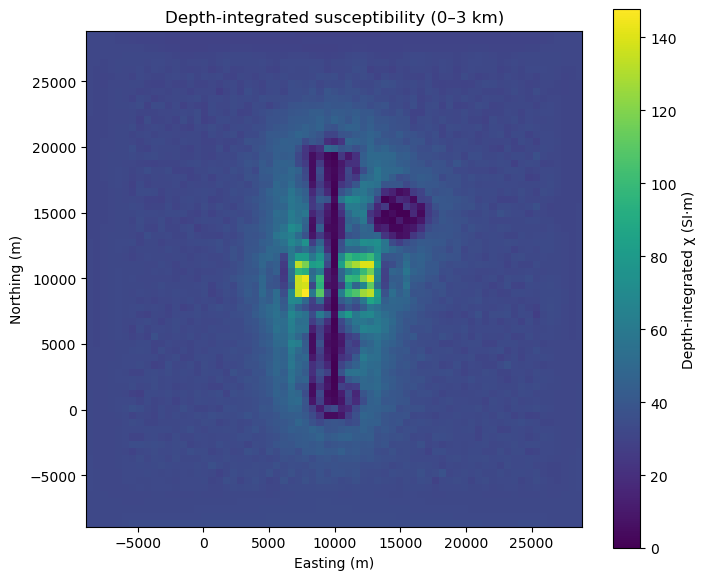

In [3]:
susc_map, x_map, y_map = depth_integrated_susceptibility(
    mesh, m_chi, actind, z_min=0.0, z_max=3_000.0
)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    susc_map.T,
    origin="lower",
    extent=[x_map.min(), x_map.max(), y_map.min(), y_map.max()],
    aspect="equal",
    cmap="viridis",
)
cb = plt.colorbar(im, ax=ax)
cb.set_label("Depth-integrated χ (SI·m)")
ax.set_title("Depth-integrated susceptibility (0–3 km)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.show()


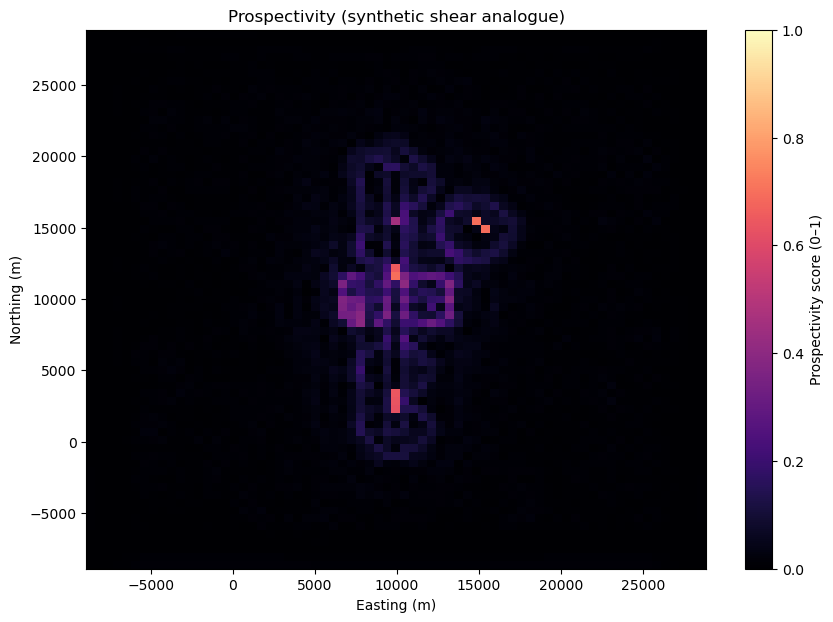

In [4]:
score = prospectivity_score(susc_map, x_map, y_map, low_susc_threshold=0.008)
plot_prospectivity(score, x_map, y_map, deposit_points=None, title="Prospectivity (synthetic shear analogue)")
